# Walmart Store Sales Forecasting: PatchTST

**MLflow experiment `PatchTST_Training`, runs in this notebook (sequential, winners carried forward):**

| Run | What it tests |
|---|---|
| PatchTST_Cleaning | shared cleaning decisions (contract from EDA) |
| PatchTST_Data_Prep | long format + weekly grid gap filling |
| PatchTST_Baseline | patch 16 / stride 8, RevIN on, hidden 128 |
| PatchTST_Patch_8_4 / 26_13 | patch geometry: how many weeks make one token |
| PatchTST_NoRevIN | ablate the built-in instance normalization |
| PatchTST_Hidden_256 | model capacity |
| PatchTST_Steps_2000 | training length |
| PatchTST_FINAL_MODEL | full-history retrain + pipeline artifact (raw test in, predictions out) |

## Setup

In [4]:
!pip install -q neuralforecast mlflow dagshub

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import neuralforecast
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import MAE
from utilsforecast.preprocessing import fill_gaps

print('neuralforecast', neuralforecast.__version__, '| mlflow', mlflow.__version__)

neuralforecast 3.2.0 | mlflow 3.14.0


In [6]:
import dagshub
from kaggle_secrets import UserSecretsClient

dagshub.auth.add_app_token(UserSecretsClient().get_secret('DAGSHUB_TOKEN'))
dagshub.init(repo_owner='Nestor-Dzadzamia', repo_name='walmart-sales-forecasting', mlflow=True)

mlflow.set_experiment('PatchTST_Training')
exp = mlflow.get_experiment_by_name('PatchTST_Training')
assert exp is not None and str(exp.experiment_id) != '0', 'runs would land in the Default experiment'
print('tracking uri:', mlflow.get_tracking_uri())
print('experiment:', exp.name, '| id:', exp.experiment_id)

Accessing as Nestor-Dzadzamia

Initialized MLflow to track repo "Nestor-Dzadzamia/walmart-sales-forecasting"

Repository Nestor-Dzadzamia/walmart-sales-forecasting initialized!

2026/07/11 17:01:45 INFO mlflow.tracking.fluent: Experiment with name 'PatchTST_Training' does not exist. Creating a new experiment.


tracking uri: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow
experiment: PatchTST_Training | id: 4


## Shared contract (copied verbatim from the EDA notebook)

In [7]:
def load_and_merge(df, features, stores):
    out = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
    out = out.merge(stores, on='Store', how='left')
    out['Date'] = pd.to_datetime(out['Date'])
    return out.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

MD_COLS = [f"MarkDown{i}" for i in range(1, 6)]

def preprocess(df):
    out = df.copy()
    out[MD_COLS] = out[MD_COLS].fillna(0)
    out[["CPI", "Unemployment"]] = out.groupby("Store")[["CPI", "Unemployment"]].ffill()
    return out

def wmae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday, 5, 1)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)

def coldstart_fallback(df_train, df_test):
    train_pairs = set(zip(df_train.Store, df_train.Dept))
    mask = ~pd.Series(list(zip(df_test.Store, df_test.Dept)), index=df_test.index).isin(train_pairs)
    cold = df_test[mask].copy()
    recent = df_train[df_train['Date'] >= df_train['Date'].max() - pd.Timedelta(weeks=52)]
    med = recent.groupby(['Type', 'Dept'])['Weekly_Sales'].median()
    cold['y_fallback'] = [med.get((t, d), 0.0) for t, d in zip(cold['Type'], cold['Dept'])]
    cold['y_fallback'] = cold['y_fallback'].clip(lower=0)
    return cold

In [8]:
path = '/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/'

train = pd.read_csv(path + 'train.csv.zip')
test = pd.read_csv(path + 'test.csv.zip')
features = pd.read_csv(path + 'features.csv.zip')
stores = pd.read_csv(path + 'stores.csv')

df = load_and_merge(train, features, stores)
df_test = load_and_merge(test, features, stores)
print('train merged:', df.shape, '| test merged:', df_test.shape)

train merged: (421570, 16) | test merged: (115064, 15)


In [9]:
with mlflow.start_run(run_name='PatchTST_Cleaning'):
    mlflow.log_param('markdown_fill', '0')
    mlflow.log_param('cpi_unemployment_fill', 'ffill_per_store')
    mlflow.log_metric('markdown_nan_before', int(df[MD_COLS].isna().sum().sum()))

    df_clean = preprocess(df)

    mlflow.log_metric('markdown_nan_after', int(df_clean[MD_COLS].isna().sum().sum()))
    mlflow.log_metric('train_rows', len(df_clean))

print(df_clean.shape)

🏃 View run PatchTST_Cleaning at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4/runs/7bdce18e410c482291463d91e94db30a
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4
(421570, 16)


In [10]:
VALIDATION_START = df_test['Date'].min() - pd.Timedelta(weeks=52)
VALIDATION_END = VALIDATION_START + pd.Timedelta(weeks=39)

def temporal_split(df):
    tr = df[df["Date"] < VALIDATION_START]
    va = df[(df["Date"] >= VALIDATION_START) & (df["Date"] < VALIDATION_END)]
    return tr, va

tr, va = temporal_split(df_clean)
print('train:', tr['Date'].max(), tr.shape)
print('val:  ', va['Date'].min(), '->', va['Date'].max(), va.shape)

train: 2011-10-28 00:00:00 (267184, 16)
val:   2011-11-04 00:00:00 -> 2012-07-27 00:00:00 (115856, 16)


## Data preparation

Identical to the previous two notebooks: long format on a regular weekly grid, missing Fridays inserted with `y=0`. PatchTST is univariate over history, so no covariate frames are needed: this cell is deliberately the simplest of the three DL notebooks.

In [11]:
HORIZON = 39
FREQ = 'W-FRI'

def to_long(frame):
    out = frame[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
    out['unique_id'] = out['Store'].astype(str) + '_' + out['Dept'].astype(str)
    out = out.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    return out[['unique_id', 'ds', 'y']].sort_values(['unique_id', 'ds']).reset_index(drop=True)

tr_long = fill_gaps(to_long(tr), freq=FREQ, start='per_serie', end='global')
n_gap_rows = int(tr_long['y'].isna().sum())
tr_long['y'] = tr_long['y'].fillna(0.0)

va_eval = va[['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']].copy()
va_eval['unique_id'] = va_eval['Store'].astype(str) + '_' + va_eval['Dept'].astype(str)

with mlflow.start_run(run_name='PatchTST_Data_Prep'):
    mlflow.log_param('format', 'long (unique_id, ds, y)')
    mlflow.log_param('gap_fill', 'insert missing Fridays, y=0')
    mlflow.log_param('covariates', 'none by design (channel-independent univariate)')
    mlflow.log_metric('n_series_train', tr_long['unique_id'].nunique())
    mlflow.log_metric('gap_rows_zero_filled', n_gap_rows)

print('series:', tr_long['unique_id'].nunique(), '| rows:', len(tr_long), f'({n_gap_rows} gap rows zero-filled)')
print('validation rows:', len(va_eval))

🏃 View run PatchTST_Data_Prep at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4/runs/379307d11214435cbd982b1f9e1651be
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4
series: 3254 | rows: 289864 (22680 gap rows zero-filled)
validation rows: 115856


## Evaluation protocol and the run helper

Identical to DLinear and N-BEATS: fit on pre-validation history, forecast 39 weeks, left-join onto validation rows (uncovered series score 0, coverage logged), shared WMAE. One helper, one MLflow run per configuration.

In [12]:
def train_and_eval(run_name, patch_len=16, stride=8, revin=True, hidden_size=128,
                   input_size=52, scaler_type='identity', max_steps=1000,
                   learning_rate=1e-3, batch_size=32, seed=42):
    model = PatchTST(h=HORIZON, input_size=input_size,
                     patch_len=patch_len, stride=stride, revin=revin,
                     hidden_size=hidden_size,
                     loss=MAE(), scaler_type=scaler_type, learning_rate=learning_rate,
                     max_steps=max_steps, batch_size=batch_size,
                     start_padding_enabled=True, random_seed=seed, logger=False, devices=1)
    nf = NeuralForecast(models=[model], freq=FREQ)
    nf.fit(df=tr_long)

    preds = nf.predict()
    if 'unique_id' not in preds.columns:
        preds = preds.reset_index()
    pred_col = [c for c in preds.columns if c not in ('unique_id', 'ds')][0]
    preds = preds.rename(columns={pred_col: 'y_hat'})

    merged = va_eval.merge(preds[['unique_id', 'ds', 'y_hat']],
                           left_on=['unique_id', 'Date'], right_on=['unique_id', 'ds'], how='left')
    coverage = float(merged['y_hat'].notna().mean())
    merged['y_hat'] = merged['y_hat'].fillna(0).clip(lower=0)

    score = float(wmae(merged['Weekly_Sales'], merged['y_hat'], merged['IsHoliday']))
    err = np.abs(merged['Weekly_Sales'] - merged['y_hat'])
    hol = merged['IsHoliday'].astype(bool)
    metrics = {'val_wmae': score,
               'val_mae': float(err.mean()),
               'val_mae_holiday': float(err[hol].mean()),
               'val_mae_regular': float(err[~hol].mean()),
               'pred_coverage': coverage}
    params = {'patch_len': patch_len, 'stride': stride, 'revin': revin,
              'hidden_size': hidden_size, 'input_size': input_size,
              'scaler_type': scaler_type, 'max_steps': max_steps,
              'learning_rate': learning_rate, 'batch_size': batch_size, 'seed': seed,
              'horizon': HORIZON, 'loss': 'MAE'}

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        for k, v in metrics.items():
            mlflow.log_metric(k, v)

    wmae_str = f'{score:,.2f}'
    print(f'{run_name}: WMAE={wmae_str} | MAE={metrics["val_mae"]:,.2f} | '
          f'holiday MAE={metrics["val_mae_holiday"]:,.2f} | coverage={coverage:.1%}')
    return {'run': run_name, **params, **metrics}, nf, merged

results = []
merged_map = {}

## Baseline

Paper-default geometry: `patch_len=16`, `stride=8` (a token = 16 weeks ~ one quarter, overlapping every 8), RevIN on, hidden size 128, input 52, raw target. The first question: does attention beat N-BEATS' 2342 out of the box?

In [13]:
res, _, m = train_and_eval('PatchTST_Baseline')
results.append(res); merged_map[res['run']] = m
print('references: N-BEATS 2342.47 | DLinear 3385.80 | LightGBM 1811')

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 430 K  | train
------------------------------------------------------------------
430 K     Trainable params
3         Non-trainable params
430 K     Total params
1.722     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run PatchTST_Baseline at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4/runs/ef9250b5ef2042f0b7ca94578404fdee
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4
PatchTST_Baseline: WMAE=2,539.67 | MAE=2,163.64 | holiday MAE=3,746.47 | coverage=99.6%
references: N-BEATS 2342.47 | DLinear 3385.80 | LightGBM 1811


## Experiment: patch geometry

What is a word in this language? With 52 weekly points per window:

- **8 / 4**: short tokens, fine local shapes, more of them (finer vocabulary),
- **16 / 8**: the paper default, quarter-length shapes,
- **26 / 13**: half-year tokens, only a few per window (coarse vocabulary).

Retail weeks have sharp local structure (holiday spikes live in 1-3 week shapes), so the hypothesis is that smaller patches help. Winner carries forward.

In [14]:
for pl, st in [(8, 4), (26, 13)]:
    res, _, m = train_and_eval(f'PatchTST_Patch_{pl}_{st}', patch_len=pl, stride=st)
    results.append(res); merged_map[res['run']] = m

fam = [r for r in results if r['run'].startswith('PatchTST_Patch') or r['run'] == 'PatchTST_Baseline']
best_patch = min(fam, key=lambda r: r['val_wmae'])
best_pl, best_st = int(best_patch['patch_len']), int(best_patch['stride'])
print(f'carrying forward patch_len={best_pl}, stride={best_st}')

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 465 K  | train
------------------------------------------------------------------
465 K     Trainable params
3         Non-trainable params
465 K     Total params
1.861     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run PatchTST_Patch_26_13 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4/runs/c0e971ac817b47c58cee6a79a8379a62
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4
PatchTST_Patch_26_13: WMAE=2,689.37 | MAE=2,275.00 | holiday MAE=4,019.23 | coverage=99.6%
carrying forward patch_len=16, stride=8


## Experiment: RevIN ablation

The scaling saga, chapter three. DLinear needed an explicit standard scaler (3460 to 3386). N-BEATS was *hurt* by one (2668 vs 2390). PatchTST ships RevIN, per-window instance normalization, on by default. Turning it off tells us whether the Transformer, like N-BEATS, can absorb scale heterogeneity by itself, or whether RevIN is load-bearing.

In [15]:
res, _, m = train_and_eval('PatchTST_NoRevIN', patch_len=best_pl, stride=best_st, revin=False)
results.append(res); merged_map[res['run']] = m

fam = [r for r in results if int(r['patch_len']) == best_pl and int(r['stride']) == best_st
       and int(r['hidden_size']) == 128 and int(r['max_steps']) == 1000]
best_revin = bool(min(fam, key=lambda r: r['val_wmae'])['revin'])
print('carrying forward revin =', best_revin)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 430 K  | train
------------------------------------------------------------------
430 K     Trainable params
3         Non-trainable params
430 K     Total params
1.722     Total estimated model params size (MB)
92        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run PatchTST_NoRevIN at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4/runs/e2ff30812f334c47addff5aad5341504
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4
PatchTST_NoRevIN: WMAE=16,305.13 | MAE=15,930.03 | holiday MAE=17,508.97 | coverage=99.6%
carrying forward revin = True


## Experiment: capacity and training length

Two checks with the winners so far: doubling `hidden_size` to 256 (is the encoder too small for 3,254 series?) and doubling training to 2000 steps (N-BEATS was converged at 1000; a Transformer may want more).

In [16]:
res, _, m = train_and_eval('PatchTST_Hidden_256', patch_len=best_pl, stride=best_st,
                           revin=best_revin, hidden_size=256)
results.append(res); merged_map[res['run']] = m

fam = [r for r in results if int(r['patch_len']) == best_pl and int(r['stride']) == best_st
       and bool(r['revin']) == best_revin and int(r['max_steps']) == 1000]
best_hidden = int(min(fam, key=lambda r: r['val_wmae'])['hidden_size'])
print('carrying forward hidden_size =', best_hidden)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 1.3 M  | train
------------------------------------------------------------------
1.3 M     Trainable params
3         Non-trainable params
1.3 M     Total params
5.013     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run PatchTST_Hidden_256 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4/runs/fdb7c0750b0b44daac7163ca688b5649
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4
PatchTST_Hidden_256: WMAE=2,620.81 | MAE=2,241.38 | holiday MAE=3,838.51 | coverage=99.6%
carrying forward hidden_size = 128


In [17]:
res, _, m = train_and_eval('PatchTST_Steps_2000', patch_len=best_pl, stride=best_st,
                           revin=best_revin, hidden_size=best_hidden, max_steps=2000)
results.append(res); merged_map[res['run']] = m

fam = [r for r in results if int(r['patch_len']) == best_pl and int(r['stride']) == best_st
       and bool(r['revin']) == best_revin and int(r['hidden_size']) == best_hidden]
best_steps = int(min(fam, key=lambda r: r['val_wmae'])['max_steps'])
print('carrying forward max_steps =', best_steps)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 430 K  | train
------------------------------------------------------------------
430 K     Trainable params
3         Non-trainable params
430 K     Total params
1.722     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=2000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run PatchTST_Steps_2000 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4/runs/a9cba95481ef491ba946219688a86607
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4
PatchTST_Steps_2000: WMAE=2,529.41 | MAE=2,161.26 | holiday MAE=3,710.92 | coverage=99.6%
carrying forward max_steps = 2000


## Results

In [18]:
results_df = pd.DataFrame(results).sort_values('val_wmae').reset_index(drop=True)
cols = ['run', 'patch_len', 'stride', 'revin', 'hidden_size', 'max_steps',
        'val_wmae', 'val_mae', 'val_mae_holiday', 'val_mae_regular', 'pred_coverage']
display(results_df[cols])
print('references: N-BEATS 2342.47 | DLinear 3385.80 | LightGBM 1811')

,run,patch_len,stride,revin,hidden_size,max_steps,val_wmae,val_mae,val_mae_holiday,val_mae_regular,pred_coverage
0,PatchTST_Steps_2000,16,8,True,128,2000,2529.412090,2161.261627,3710.920123,2030.347680,0.996435
1,PatchTST_Baseline,16,8,True,128,1000,2539.673371,2163.644500,3746.465638,2029.928998,0.996435
2,PatchTST_Patch_8_4,8,4,True,128,1000,2615.918394,2217.061048,3895.974256,2075.227763,0.996435
3,PatchTST_Hidden_256,16,8,True,256,1000,2620.810166,2241.382577,3838.509966,2106.458495,0.996435
4,PatchTST_Patch_26_13,26,13,True,128,1000,2689.371416,2274.997175,4019.225768,2127.646096,0.996435
5,PatchTST_NoRevIN,16,8,False,128,1000,16305.133116,15930.026580,17508.965329,15796.639059,0.996435


references: N-BEATS 2342.47 | DLinear 3385.80 | LightGBM 1811


## Error analysis of the best run

Same two views as the previous notebooks, plus the DL-track holiday comparison: DLinear 4605 -> N-BEATS 3141 -> PatchTST ?

best run: PatchTST_Steps_2000


/tmp/ipykernel_58/1834974901.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_week = best.groupby('Date').apply(lambda g: wmae(g['Weekly_Sales'], g['y_hat'], g['IsHoliday']))


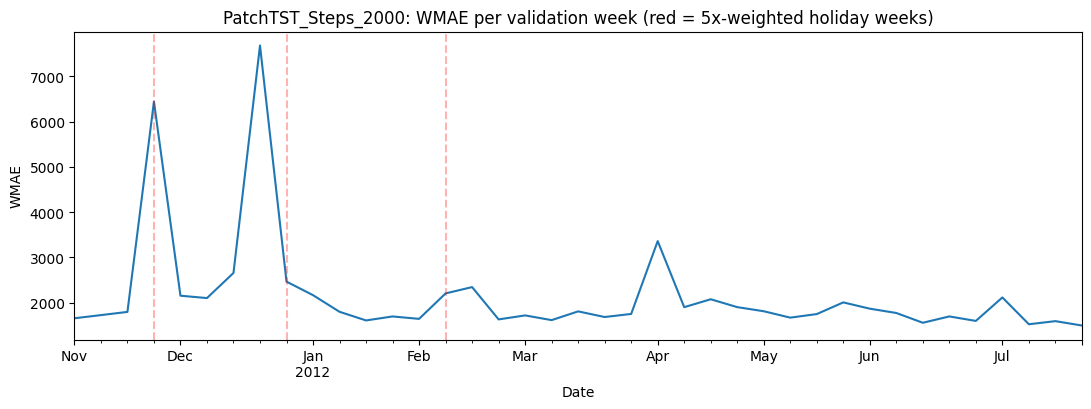

In [19]:
best_run_name = results_df.iloc[0]['run']
best = merged_map[best_run_name]
print('best run:', best_run_name)

by_week = best.groupby('Date').apply(lambda g: wmae(g['Weekly_Sales'], g['y_hat'], g['IsHoliday']))
hol_weeks = best.loc[best['IsHoliday'].astype(bool), 'Date'].unique()

fig, ax = plt.subplots(figsize=(13, 4))
by_week.plot(ax=ax)
for d in hol_weeks:
    ax.axvline(d, color='red', alpha=0.3, linestyle='--')
ax.set_title(f'{best_run_name}: WMAE per validation week (red = 5x-weighted holiday weeks)')
ax.set_ylabel('WMAE')
plt.show()

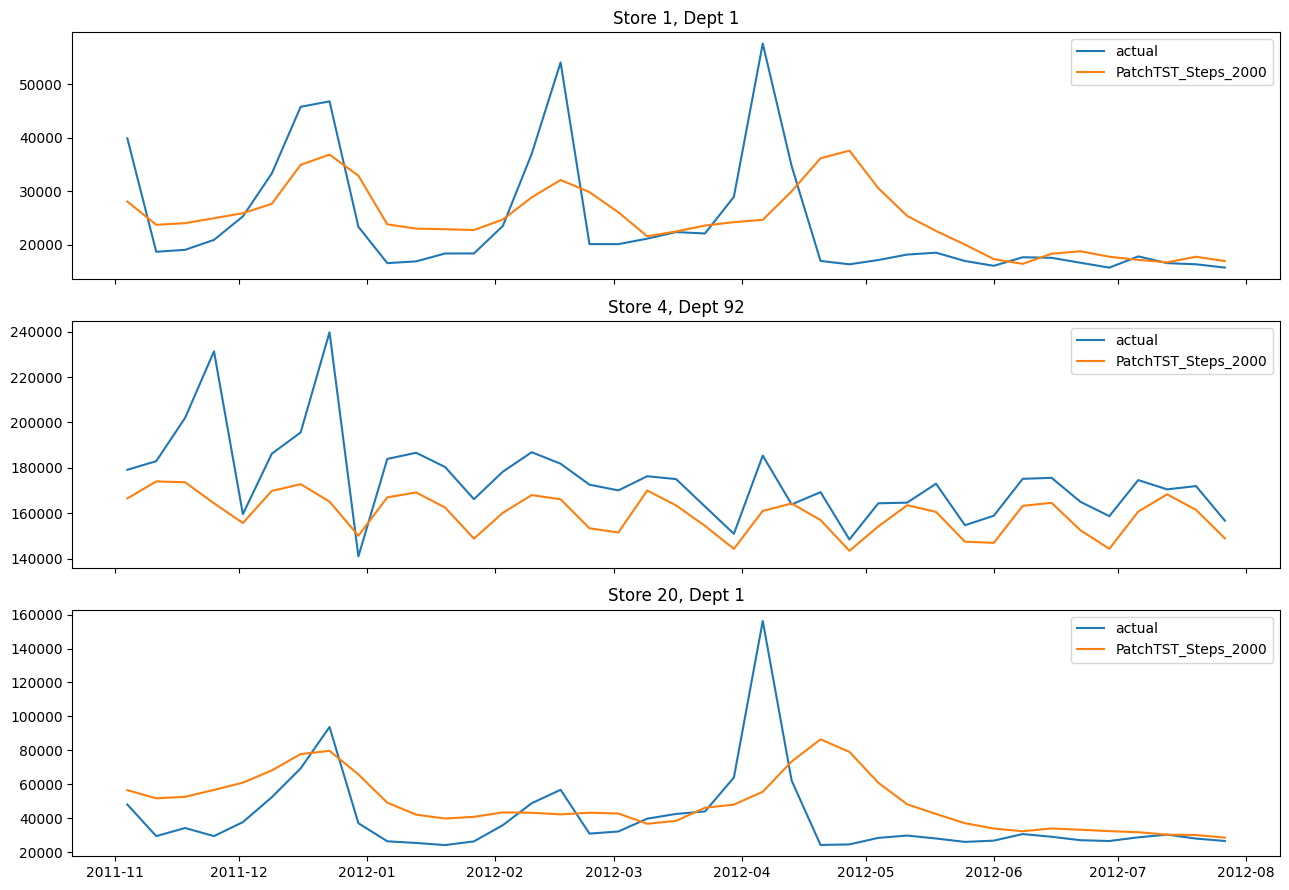

holiday MAE: DLinear 4605 -> N-BEATS 3141 -> PatchTST 3,711 (+18.1% vs N-BEATS)


In [20]:
examples = [(1, 1), (4, 92), (20, 1)]
fig, axes = plt.subplots(len(examples), 1, figsize=(13, 9), sharex=True)
for ax, (s, d) in zip(axes, examples):
    sub = best[(best['Store'] == s) & (best['Dept'] == d)].sort_values('Date')
    ax.plot(sub['Date'], sub['Weekly_Sales'], label='actual')
    ax.plot(sub['Date'], sub['y_hat'], label=best_run_name)
    ax.set_title(f'Store {s}, Dept {d}')
    ax.legend()
plt.tight_layout(); plt.show()

nb_holiday = 3141.40
pt_holiday = float(results_df.iloc[0]['val_mae_holiday'])
print(f'holiday MAE: DLinear 4605 -> N-BEATS 3141 -> PatchTST {pt_holiday:,.0f} '
      f'({(pt_holiday / nb_holiday - 1) * 100:+.1f}% vs N-BEATS)')

## Final model: retrain on full history

Per shared decision #6: winning configuration retrained on all 143 weeks, 39 test weeks forecast, cold-start rows via the shared fallback, clip at 0, submission written.

In [21]:
best_row = results_df.iloc[0]
best_cfg = {'patch_len': int(best_row['patch_len']), 'stride': int(best_row['stride']),
            'revin': bool(best_row['revin']), 'hidden_size': int(best_row['hidden_size']),
            'input_size': int(best_row['input_size']), 'scaler_type': str(best_row['scaler_type']),
            'max_steps': int(best_row['max_steps'])}
best_val_wmae = float(best_row['val_wmae'])
print('final config:', best_cfg, '| validated WMAE:', round(best_val_wmae, 2))

full_long = fill_gaps(to_long(df_clean), freq=FREQ, start='per_serie', end='global')
full_long['y'] = full_long['y'].fillna(0.0)

final_model = PatchTST(h=HORIZON, input_size=best_cfg['input_size'],
                       patch_len=best_cfg['patch_len'], stride=best_cfg['stride'],
                       revin=best_cfg['revin'], hidden_size=best_cfg['hidden_size'],
                       loss=MAE(), scaler_type=best_cfg['scaler_type'], learning_rate=1e-3,
                       max_steps=best_cfg['max_steps'], batch_size=32,
                       start_padding_enabled=True, random_seed=42, logger=False, devices=1)
nf_final = NeuralForecast(models=[final_model], freq=FREQ)
nf_final.fit(df=full_long)
print('final model trained on', full_long['unique_id'].nunique(), 'series,', len(full_long), 'rows')

final config: {'patch_len': 16, 'stride': 8, 'revin': True, 'hidden_size': 128, 'input_size': 52, 'scaler_type': 'identity', 'max_steps': 2000} | validated WMAE: 2529.41


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 430 K  | train
------------------------------------------------------------------
430 K     Trainable params
3         Non-trainable params
430 K     Total params
1.722     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=2000` reached.


final model trained on 3331 series, 462053 rows


In [22]:
preds_test = nf_final.predict()
if 'unique_id' not in preds_test.columns:
    preds_test = preds_test.reset_index()
pred_col = [c for c in preds_test.columns if c not in ('unique_id', 'ds')][0]
preds_test = preds_test.rename(columns={pred_col: 'y_hat'})

test_pred = df_test[['Store', 'Dept', 'Date']].copy()
test_pred['unique_id'] = test_pred['Store'].astype(str) + '_' + test_pred['Dept'].astype(str)
test_pred = test_pred.merge(preds_test[['unique_id', 'ds', 'y_hat']],
                            left_on=['unique_id', 'Date'], right_on=['unique_id', 'ds'], how='left')
print('test rows without model forecast (expect 36 cold-start rows):', int(test_pred['y_hat'].isna().sum()))

cold = coldstart_fallback(df_clean, df_test)
test_pred = test_pred.merge(cold[['Store', 'Dept', 'Date', 'y_fallback']],
                            on=['Store', 'Dept', 'Date'], how='left')
test_pred['Weekly_Sales'] = test_pred['y_fallback'].combine_first(test_pred['y_hat']).fillna(0).clip(lower=0)

submission = test_pred[['Store', 'Dept', 'Date']].copy()
submission['Id'] = (submission['Store'].astype(str) + '_' + submission['Dept'].astype(str)
                    + '_' + submission['Date'].dt.strftime('%Y-%m-%d'))
submission['Weekly_Sales'] = test_pred['Weekly_Sales']
submission = submission[['Id', 'Weekly_Sales']].sort_values('Id').reset_index(drop=True)
assert len(submission) == len(test), f'row mismatch: {len(submission)} vs {len(test)}'
submission.to_csv('submission_patchtst.csv', index=False)
print(submission.shape)
submission.head()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

test rows without model forecast (expect 36 cold-start rows): 36
(115064, 2)


,Id,Weekly_Sales
0,10_10_2012-11-02,44492.187500
1,10_10_2012-11-09,44957.886719
2,10_10_2012-11-16,44954.175781
3,10_10_2012-11-23,48367.394531
4,10_10_2012-11-30,47032.261719


## Pipeline artifact (assignment requirement)

Same verified pattern: raw `test.csv` frame in, final predictions out (merge, preprocess, forecast, cold-start fallback, clip). Logged with `mlflow.pyfunc`; the next cell loads it back from DagsHub and checks it reproduces this notebook exactly.

**Known limitation (by design, teammate review 2026-07-11):** the wrapped forecaster is fixed-horizon. `nf.predict()` always produces the 39 weeks immediately after the training history; the input frame selects rows, it does not trigger recomputation. The pipeline therefore raises a clear error if asked for dates outside that horizon instead of silently returning fallback values.

In [23]:
nf_final.save(path='nf_patchtst', overwrite=True, save_dataset=True)
df_clean.to_parquet('train_clean.parquet')
features.to_parquet('features.parquet')
stores.to_parquet('stores.parquet')

class PatchTSTPipeline(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        from neuralforecast import NeuralForecast
        self.nf = NeuralForecast.load(context.artifacts['nf_model'])
        self.train_clean = pd.read_parquet(context.artifacts['train_clean'])
        self.features = pd.read_parquet(context.artifacts['features'])
        self.stores = pd.read_parquet(context.artifacts['stores'])

    def predict(self, context, model_input):
        clean = preprocess(load_and_merge(model_input.copy(), self.features, self.stores))

        preds = self.nf.predict()
        if 'unique_id' not in preds.columns:
            preds = preds.reset_index()
        pred_col = [c for c in preds.columns if c not in ('unique_id', 'ds')][0]
        preds = preds.rename(columns={pred_col: 'y_hat'})

        horizon_ds = set(pd.to_datetime(preds['ds'].unique()))
        requested = set(pd.to_datetime(clean['Date'].unique()))
        outside = sorted(d for d in requested if d not in horizon_ds)
        if outside:
            raise ValueError(
                f'{len(outside)} requested dates fall outside the fixed 39-week forecast horizon '
                f'(first: {outside[0].date()}). This pipeline forecasts only the 39 weeks '
                f'immediately after its training history; retrain to forecast other ranges.')

        out = clean[['Store', 'Dept', 'Date']].copy()
        out['unique_id'] = out['Store'].astype(str) + '_' + out['Dept'].astype(str)
        out = out.merge(preds[['unique_id', 'ds', 'y_hat']],
                        left_on=['unique_id', 'Date'], right_on=['unique_id', 'ds'], how='left')
        cold = coldstart_fallback(self.train_clean, clean)
        out = out.merge(cold[['Store', 'Dept', 'Date', 'y_fallback']],
                        on=['Store', 'Dept', 'Date'], how='left')
        out['Weekly_Sales'] = out['y_fallback'].combine_first(out['y_hat']).fillna(0).clip(lower=0)
        return out[['Store', 'Dept', 'Date', 'Weekly_Sales']]

with mlflow.start_run(run_name='PatchTST_FINAL_MODEL') as run:
    mlflow.log_params(best_cfg)
    mlflow.log_param('trained_on', 'full_history_143_weeks')
    mlflow.log_param('coldstart', 'shared coldstart_fallback')
    mlflow.log_metric('validation_wmae', best_val_wmae)
    model_info = mlflow.pyfunc.log_model(
        artifact_path='model',
        python_model=PatchTSTPipeline(),
        artifacts={'nf_model': 'nf_patchtst',
                   'train_clean': 'train_clean.parquet',
                   'features': 'features.parquet',
                   'stores': 'stores.parquet'},
        pip_requirements=[f'neuralforecast=={neuralforecast.__version__}', 'pandas', 'pyarrow'],
    )
    final_run_id = run.info.run_id

print('final run id:', final_run_id)
print('model uri:', model_info.model_uri)

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/07/11 17:06:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 17:06:21 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run PatchTST_FINAL_MODEL at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4/runs/18a50d95f16e4055aa65b0eafa3194cf
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/4
final run id: 18a50d95f16e4055aa65b0eafa3194cf
model uri: models:/m-89431f095d2f41efb70141e0dc5bf944


In [24]:
loaded = mlflow.pyfunc.load_model(model_info.model_uri)
pipe_out = loaded.predict(test)

check = test_pred[['Store', 'Dept', 'Date', 'Weekly_Sales']].merge(
    pipe_out, on=['Store', 'Dept', 'Date'], suffixes=('_nb', '_pipe'))
assert len(check) == len(test), 'pipeline did not return every test row'
max_diff = float((check['Weekly_Sales_nb'] - check['Weekly_Sales_pipe']).abs().max())
print('max abs diff notebook vs pipeline:', max_diff)
assert max_diff < 1.0
print('PIPELINE SMOKE TEST PASSED: raw test.csv in, final predictions out')

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

max abs diff notebook vs pipeline: 0.0
PIPELINE SMOKE TEST PASSED: raw test.csv in, final predictions out


## Conclusions

- Baseline WMAE 2539.67; best run PatchTST_Steps_2000, WMAE **2529.41** (patch 16 / stride 8, RevIN on, hidden 128, 2000 steps, raw target).
- **DL track final standings: DLinear 3385.80, PatchTST 2529.41, N-BEATS 2342.47** vs LightGBM 1811. Attention did NOT beat the MLP residual blocks on this dataset: with only 91 weekly points per training window there is not enough history for attention to out-learn structured blocks. This echoes the caution of the DLinear paper about Transformers on short series, and it makes N-BEATS the deep learning track's best model.
- Patch geometry: the paper default won. Finer tokens (8/4: 2616) and coarser tokens (26/13: 2689) both lost to 16/8; quarter-length shapes appear to be the right vocabulary for weekly retail data.
- **RevIN ablation, the scaling saga's finale: removing it collapsed the model to WMAE 16,305**, roughly the level of predicting zero everywhere. Full arc across the track: DLinear was helped by an explicit scaler (3460 to 3386), N-BEATS was hurt by one (2668 vs 2390), PatchTST cannot function without its built-in per-window normalization at all. Attention over raw magnitudes across series spanning five orders of magnitude simply fails; normalization is load-bearing, not cosmetic.
- Capacity and steps: doubling the encoder overfit (2621); doubling training helped slightly (2529 vs 2540), so the Transformer, unlike N-BEATS, was still improving at 1000 steps.
- Holiday MAE trajectory: 4605 (DLinear) -> 3141 (N-BEATS) -> 3711 (PatchTST): attention did not localize the 5x-weighted holiday spikes better than the residual blocks.
- Team-wide best model for model_inference.ipynb and the Model Registry: **LightGBM (1811)**; deep learning track's best: **N-BEATS (2342.47)**.
- Final pipeline logged to MLflow and verified (max diff vs notebook 0.0), including the fixed-horizon date-range guard added after teammate review.